In [1]:
import numpy as np
print(np.__version__)

2.3.3


In [8]:
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [3]:
model = joblib.load("../models/xgboost_best.pkl")

In [5]:
df = pd.read_csv("../data/processed/processed_data.csv")

In [7]:
X = df.drop("Churn Label" , axis = 1)
y = df["Churn Label"]

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
explainer = shap.TreeExplainer(model)

In [11]:
shap_values = explainer.shap_values(X_test)

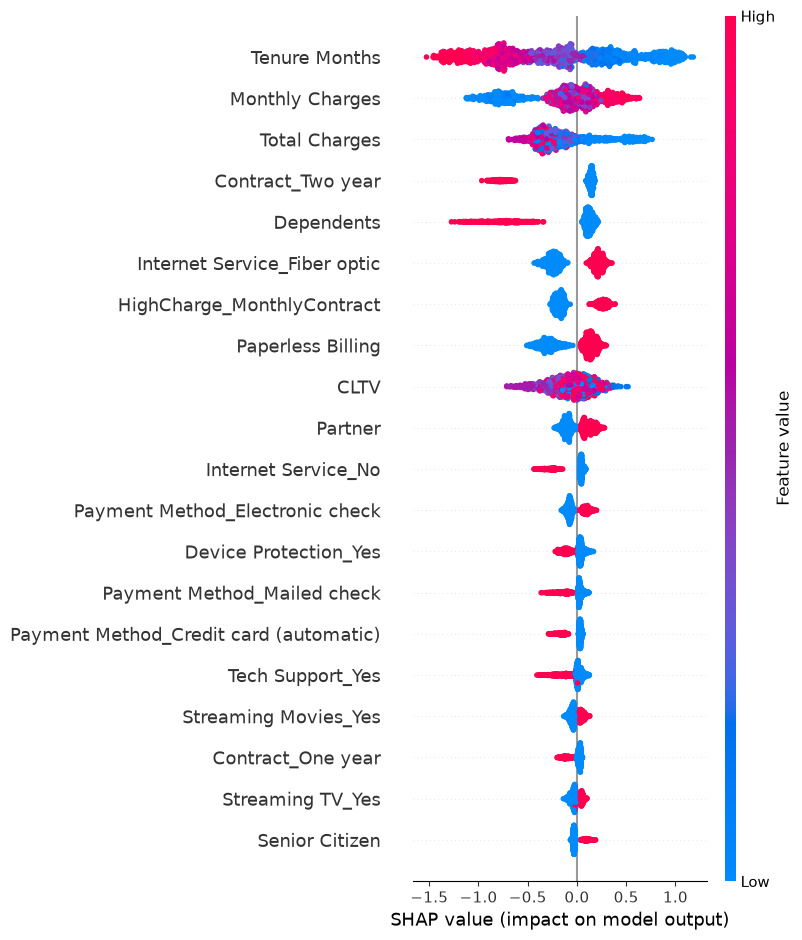

In [13]:
shap.summary_plot(shap_values, X_test)

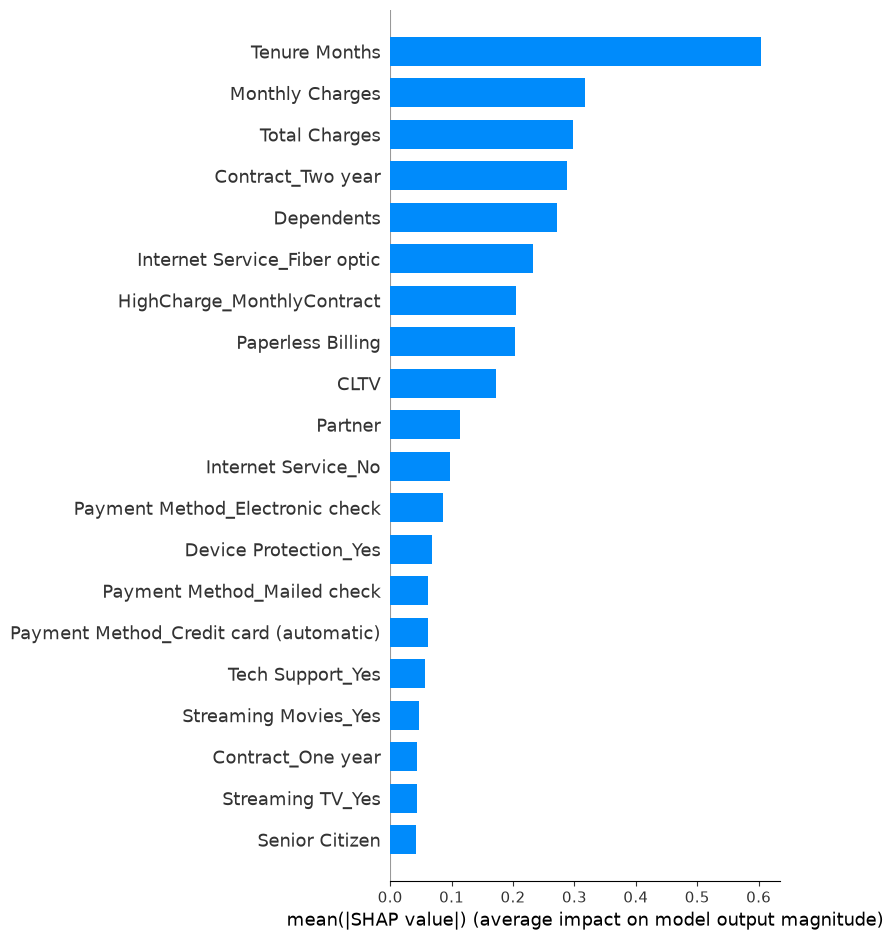

In [14]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

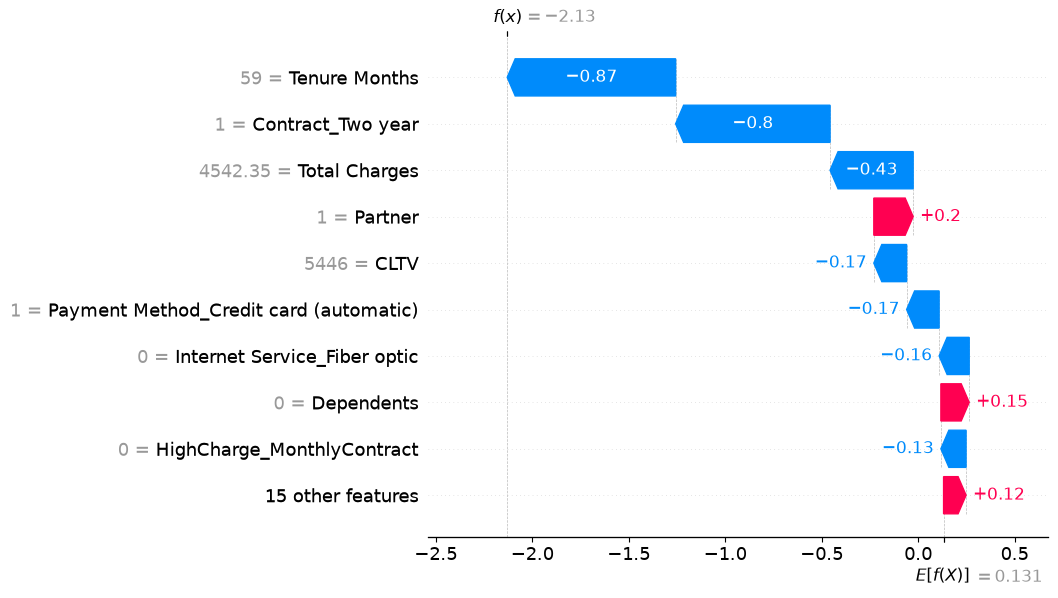

In [15]:
customer = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer],
        base_values=explainer.expected_value,
        data=X_test.iloc[customer],
        feature_names=X_test.columns
    )
)

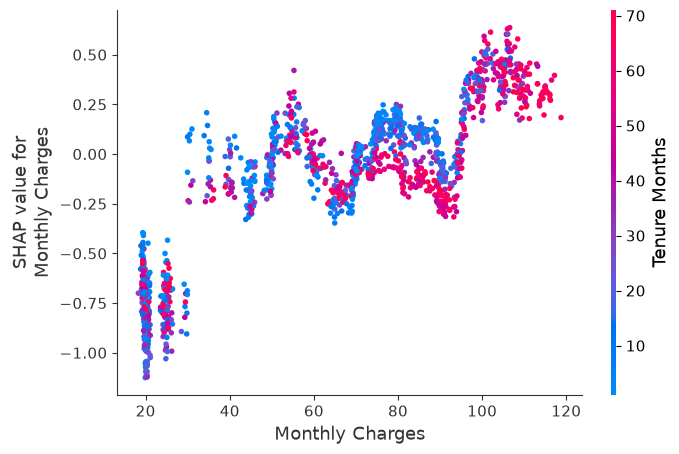

In [17]:
shap.dependence_plot(
    "Monthly Charges",
    shap_values,
    X_test
)